<a href="https://colab.research.google.com/github/elijahmflomo/Sem_2_GENERATIVE-AI/blob/main/Gen_Ai_LAB_TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import zipfile
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# 1. Set the Kaggle API Token directly
# This allows us to download the dataset without manual file uploads
os.environ['KAGGLE_API_TOKEN'] = "KGAT_27e37dd9804cc739b13a71e23e07bb09"

In [9]:
# 2. Download the dataset using the Kaggle CLI
print("Fetching dataset from Kaggle... (this may take a moment)")
!kaggle datasets download -d moltean/fruits

# 3. Unzip the dataset
if os.path.exists('fruits.zip'):
    print("Unzipping dataset...")
    with zipfile.ZipFile('fruits.zip', 'r') as zip_ref:
        zip_ref.extractall('fruits_data')
    print("Extraction Complete.")

Fetching dataset from Kaggle... (this may take a moment)
Dataset URL: https://www.kaggle.com/datasets/moltean/fruits
License(s): CC-BY-SA-4.0
fruits.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping dataset...
Extraction Complete.


In [10]:
# This will show  the top-level folders
print("Top level folders:", os.listdir('fruits_data'))

# This will find where 'Training' actually is
for root, dirs, files in os.walk('fruits_data'):
    if 'Training' in dirs:
        print("Found the Training folder at:", os.path.join(root, 'Training'))
        break

Top level folders: ['fruits-360_original-size', 'fruits-360_3-body-problem', 'fruits-360_meta', 'fruits-360_100x100', 'fruits-360_multi']
Found the Training folder at: fruits_data/fruits-360_original-size/fruits-360-original-size/Training


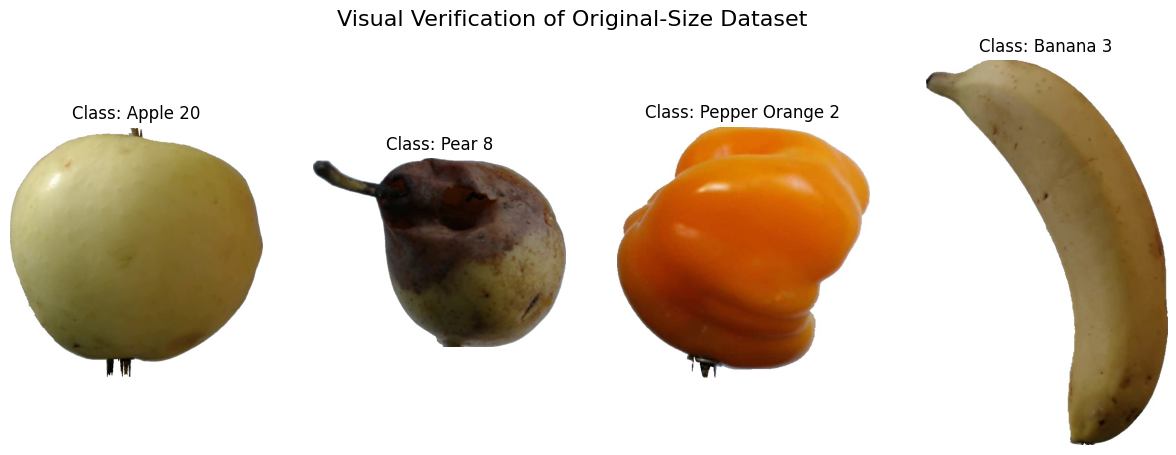


Successfully identified folders: ['Apple 20', 'Pear 8', 'Pepper Orange 2', 'Banana 3']
Image Resolution: 529x845 pixels


In [11]:
# 1. SET THE CORRECT PATH
train_path = 'fruits_data/fruits-360_original-size/fruits-360-original-size/Training'

# 2. Define the fruits looking for
target_keywords = ['Apple', 'Pear', 'Orange', 'Banana']

# 3. Automatically find the exact folder names in that directory
all_folders = os.listdir(train_path)
selected_folders = []

for keyword in target_keywords:
    # Find folders that contain the fruit name (case-insensitive)
    matches = [f for f in all_folders if keyword.lower() in f.lower()]
    if matches:
        selected_folders.append(matches[0]) # Take the first match (e.g., 'apple_1')

# 4. Visualize the images
plt.figure(figsize=(15, 5))

# We use the folders we actually found
for i, fruit_folder in enumerate(selected_folders):
    fruit_dir = os.path.join(train_path, fruit_folder)

    # Pick a random image from the folder
    random_sample = random.choice(os.listdir(fruit_dir))
    img_path = os.path.join(fruit_dir, random_sample)

    img = mpimg.imread(img_path)

    plt.subplot(1, len(selected_folders), i+1)
    plt.imshow(img)
    plt.title(f"Class: {fruit_folder}")
    plt.axis('off')

plt.suptitle("Visual Verification of Original-Size Dataset", fontsize=16)
plt.show()

# Quick summary for your records
print(f"\nSuccessfully identified folders: {selected_folders}")
print(f"Image Resolution: {img.shape[1]}x{img.shape[0]} pixels")

In [14]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. SETUP DATA LOADING
# Use the path verified in the previous step
train_dir = 'fruits_data/fruits-360_original-size/fruits-360-original-size/Training'
# Use the exact folder names found in your screenshot
selected_classes = ['Apple 20', 'Pear 8', 'Pepper Orange 2', 'Banana 3']

# Pre-processing: Scale pixels to [0,1] and split 20% for validation
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    classes=selected_classes,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    classes=selected_classes,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Keep false for clean confusion matrix
)



Found 1251 images belonging to 4 classes.
Found 310 images belonging to 4 classes.


In [21]:
# 2. BUILD THE CNN MODEL
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Prevents overfitting
    layers.Dense(4, activation='softmax') # 4 Output neurons
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. TRAIN THE MODEL (Running for 10 epochs)
print("\nTraining starting...")
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

# 4. EVALUATION & VISUALIZATION
plt.figure(figsize=(18, 5))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training starting...
Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 192ms/step - accuracy: 0.8058 - loss: 0.5278 - val_accuracy: 1.0000 - val_loss: 0.0520
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9848 - loss: 0.0569 - val_accuracy: 1.0000 - val_loss: 0.0267
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.9920 - loss: 0.0324 - val_accuracy: 0.9935 - val_loss: 0.0257
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.9976 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 3.4107e-04
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 125ms/step - accuracy: 0.9976 - loss: 0.0086 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 1.0731e-04
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 134ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 1.0000 - val_loss: 1.5269e-04
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 1.000

<Figure size 1800x500 with 0 Axes>

<Figure size 1800x500 with 0 Axes>

In [26]:
# 1. Get the final epoch values directly from the history object
final_train_acc = history.history['accuracy'][-1] * 100
final_val_acc = history.history['val_accuracy'][-1] * 100

# 2. Run a formal evaluation on the validation dataset
print("Evaluating model on validation data...")
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)

print("-" * 30)
print(f"Final Training Accuracy:   {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy * 100:.2f}%")
print("-" * 30)



Evaluating model on validation data...
------------------------------
Final Training Accuracy:   99.84%
Final Validation Accuracy: 100.00%
------------------------------


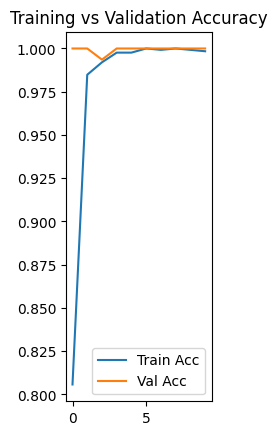

In [27]:
# Plot Accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.legend()





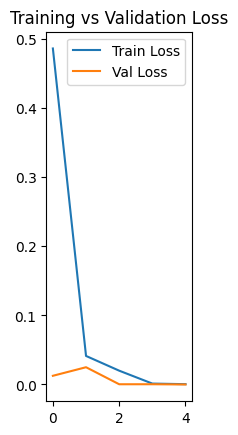

In [18]:
# Plot Loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.legend()

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step


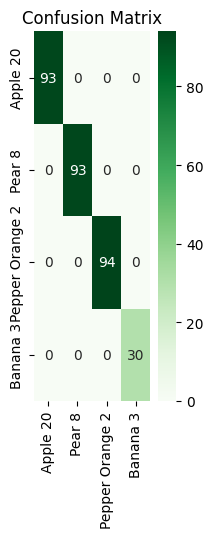


Model trained successfully!


In [24]:
# Confusion Matrix
plt.subplot(1, 3, 3)
Y_pred = model.predict(val_generator)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(val_generator.classes, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=selected_classes, yticklabels=selected_classes)
plt.title('Confusion Matrix')
plt.show()

print("\nModel trained successfully!")